# Notebook 3 — Cohort Health Score M = median(cohort) / days_i

**Per-entity metric:** For each entity `i` in a cohort, their score is:

```
m_i = median(cohort) / days_i
```

- `m_i > 1`: entity got traffic **faster** than the cohort median (fewer days than median)
- `m_i = 1`: entity is exactly at the median
- `m_i < 1`: entity is a **laggard** — took more days than the typical entity

**Cohort-level summary:** `M = mean(m_i) = mean(median(cohort) / days_i)`

Note: due to Jensen's inequality (E[1/X] > 1/E[X]), M > 1 for any cohort with variance.
The meaningful signal is the *relative* M across cohorts — a bimodal cohort with a heavy
slow tail will show a higher M because the fast cluster dominates the harmonic average.

- Higher M = fast entities dominate; slow entities contribute little (their scores → 0)
- Lower M (closer to 1) = more uniform distribution; laggards are dragging scores down

We compare M across four cohort scenarios.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from time_to_traffic_sim.gamma_params import fit_gamma_params, describe_distribution
from time_to_traffic_sim.simulation import simulate_cohorts, simulate_mixed_cohort
from time_to_traffic_sim.metrics import summarize_metric_distribution

In [2]:
import yaml
with open('../config.yaml') as f:
    config = yaml.safe_load(f)

MODE_DAYS          = config['gamma']['mode_days']
MEDIAN_DAYS        = config['gamma']['median_days']
COHORT_SIZES       = config['simulation']['cohort_sizes']
N_SIMS             = config['simulation']['n_simulations']
SEED               = config['simulation']['random_seed']
NEVER_TRAFFIC_FRAC = config['simulation']['never_traffic_fraction']
NEVER_TRAFFIC_DAYS = config['simulation']['never_traffic_days']

# Scenario parameters from config; colors and type are notebook-local
_sc = config['scenarios']
SCENARIOS = {
    _sc['baseline']['label']:        dict(type='simple', theta_mult=_sc['baseline']['theta_multiplier'],        color='steelblue'),
    _sc['high_performing']['label']: dict(type='simple', theta_mult=_sc['high_performing']['theta_multiplier'], color='green'),
    _sc['low_performing']['label']:  dict(type='simple', theta_mult=_sc['low_performing']['theta_multiplier'],  color='red'),
    _sc['mixed']['label']:           dict(type='mixed',
                                         fast_frac=_sc['mixed']['fast_fraction'],
                                         fast_mult=_sc['mixed']['fast_theta_multiplier'],
                                         slow_mult=_sc['mixed']['slow_theta_multiplier'],
                                         color='purple'),
}

print(f'Config: mode={MODE_DAYS} d, median={MEDIAN_DAYS} d')
print(f'  cohort_sizes={COHORT_SIZES}, n_sims={N_SIMS}, seed={SEED}')
print(f'  never-traffic={NEVER_TRAFFIC_FRAC:.0%} at {NEVER_TRAFFIC_DAYS:.0f} d')
print(f'  scenarios: {list(SCENARIOS.keys())}')

Config: mode=7.0 d, median=45.0 d
  cohort_sizes=[20, 50, 100, 250], n_sims=5000, seed=42
  never-traffic=1% at 400 d
  scenarios: ['Baseline', 'High-Performing', 'Low-Performing', 'Mixed (Bimodal)']


In [3]:
k, theta = fit_gamma_params(mode_days=MODE_DAYS, median_days=MEDIAN_DAYS)


def run_scenario(name, sc_cfg, cohort_size):
    rng = np.random.default_rng(SEED)
    if sc_cfg['type'] == 'simple':
        return simulate_cohorts(
            k, theta * sc_cfg['theta_mult'],
            cohort_size=cohort_size, n_simulations=N_SIMS,
            never_traffic_fraction=NEVER_TRAFFIC_FRAC,
            never_traffic_days=NEVER_TRAFFIC_DAYS,
            rng=rng,
        )
    else:
        return simulate_mixed_cohort(
            k, theta, cohort_size=cohort_size, n_simulations=N_SIMS,
            fast_fraction=sc_cfg['fast_frac'],
            fast_theta_multiplier=sc_cfg['fast_mult'],
            slow_theta_multiplier=sc_cfg['slow_mult'],
            never_traffic_fraction=NEVER_TRAFFIC_FRAC,
            never_traffic_days=NEVER_TRAFFIC_DAYS,
            rng=rng,
        )


print(f'Distribution: Gamma(k={k:.4f}, θ={theta:.2f}) + {NEVER_TRAFFIC_FRAC:.0%} point mass at {NEVER_TRAFFIC_DAYS:.0f} d')
print('Running simulations...')
sim_data = {}
for name, sc_cfg in SCENARIOS.items():
    sim_data[name] = {n: run_scenario(name, sc_cfg, n) for n in COHORT_SIZES}
print('Done.')

Distribution: Gamma(k=1.1270, θ=55.10) + 1% point mass at 400 d
Running simulations...
Done.


## M Distribution by Scenario

Violin plot of M for each scenario at cohort size N=100. Fast cohorts and bimodal cohorts produce higher, more variable M. The dashed line at M=1 is the degenerate lower bound (all entities at identical speed).

/tmp/ipykernel_2177470/683876457.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long_df, x='Scenario', y='M', palette=palette, inner='quartile', ax=ax)


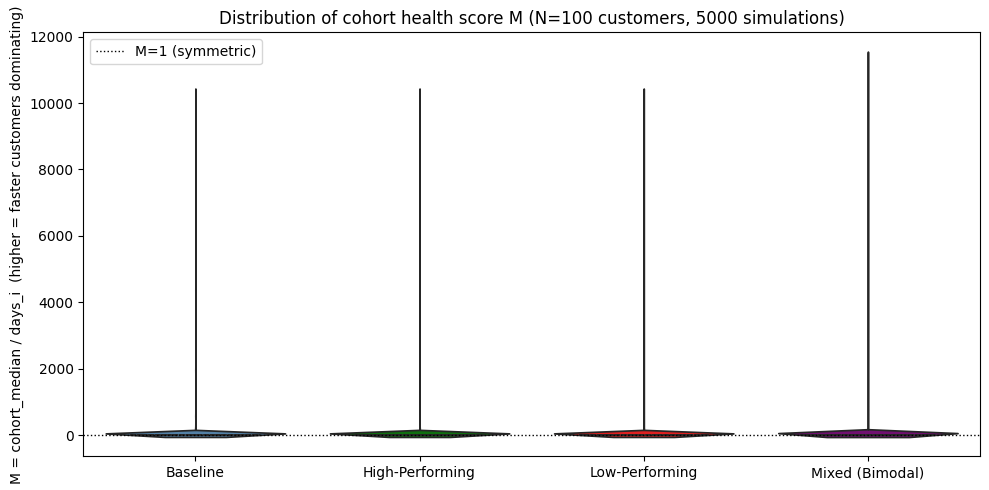

In [4]:
# Violin plot: distribution of M across scenarios for cohort size N=100
N_FOCUS = 100

frames = []
for name, by_size in sim_data.items():
    df = by_size[N_FOCUS]
    frames.append(pd.DataFrame({'M': df['mean_score'], 'Scenario': name}))
long_df = pd.concat(frames, ignore_index=True)

palette = {name: cfg['color'] for name, cfg in SCENARIOS.items()}

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=long_df, x='Scenario', y='M', palette=palette, inner='quartile', ax=ax)
ax.axhline(1.0, color='black', ls=':', lw=1, label='M=1 (symmetric)')
ax.set_title(f'Distribution of cohort health score M (N={N_FOCUS} entities, {N_SIMS} simulations)')
ax.set_ylabel('M = cohort_median / days_i  (higher = faster entities dominating)')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.savefig('../output/03_violin_M_by_scenario.png', dpi=150)
plt.show()

## M Stability vs Cohort Size

How much does M vary as cohort size grows? Larger cohorts tighten the 90% band and reduce noise in the metric, making it more reliable as a monitoring signal.

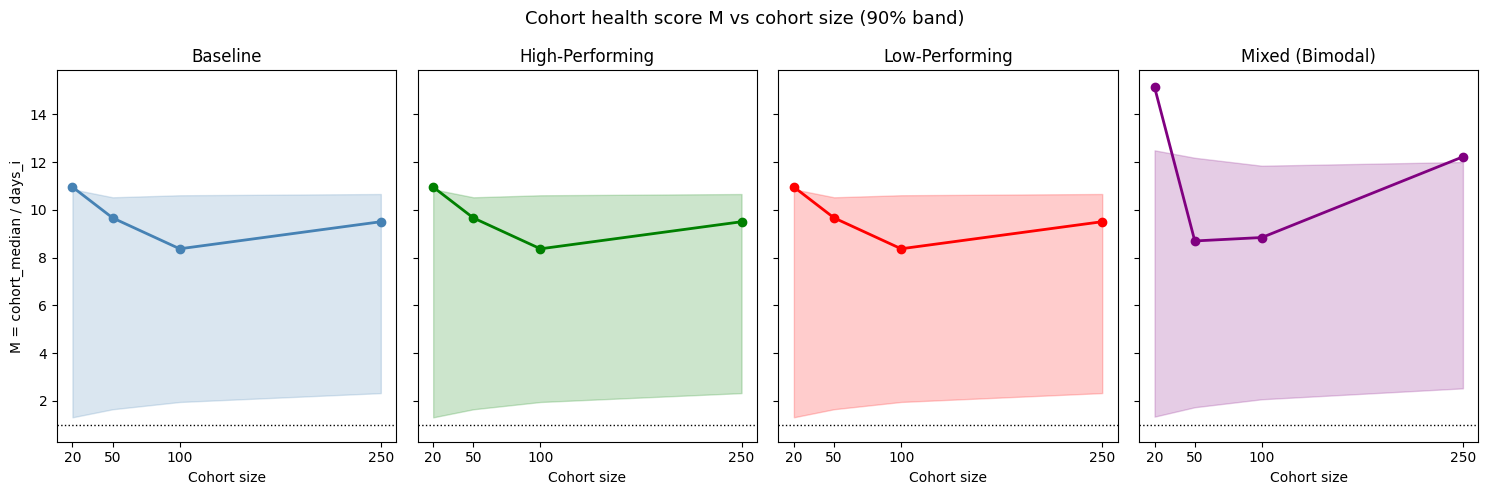

In [5]:
# How does M shift with cohort size? (Mean ± 90% band across simulations)
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(15, 5), sharey=True)

for ax, (name, by_size) in zip(axes, sim_data.items()):
    sizes, means, p5s, p95s = [], [], [], []
    for n, df in sorted(by_size.items()):
        scores = df['mean_score'].to_numpy()
        s = summarize_metric_distribution(scores)
        sizes.append(n)
        means.append(s['mean'])
        p5s.append(s['p5'])
        p95s.append(s['p95'])

    ax.plot(sizes, means, 'o-', color=SCENARIOS[name]['color'], lw=2, label='Mean M')
    ax.fill_between(sizes, p5s, p95s, alpha=0.2, color=SCENARIOS[name]['color'], label='5–95th pct')
    ax.axhline(1.0, color='black', ls=':', lw=1)
    ax.set_title(name)
    ax.set_xlabel('Cohort size')
    ax.set_xticks(COHORT_SIZES)

axes[0].set_ylabel('M = cohort_median / days_i')
fig.suptitle('Cohort health score M vs cohort size (90% band)', fontsize=13)
plt.tight_layout()
plt.savefig('../output/03_M_vs_cohort_size.png', dpi=150)
plt.show()

## Summary Scorecard

Tabulate M (mean ± std) and the 90% confidence interval across all scenario × cohort-size combinations. Use this to set expected healthy ranges for monitoring.

In [ ]:
# Scorecard: M (mean ± std) for every scenario × cohort size
rows = []
for name, by_size in sim_data.items():
    for n, df in sorted(by_size.items()):
        scores = df['mean_score'].to_numpy()
        s = summarize_metric_distribution(scores)
        rows.append({
            'Scenario': name,
            'N': n,
            'M (mean ± std)': f"{s['mean']:.3f} ± {s['std']:.3f}",
            '95% CI': f"[{s['p5']:.3f}, {s['p95']:.3f}]",
            'Avg mean days': f"{df['cohort_mean'].mean():.1f}",
            'Avg median days': f"{df['cohort_median'].mean():.1f}",
        })

scorecard = pd.DataFrame(rows)
print('Cohort Health Score Scorecard  (M = mean(cohort_median/days_i); higher = fast entities dominating)\n')
print(scorecard.to_string(index=False))

## Mean Days vs M: Separating Scenarios

KDE comparison of raw mean days and M across scenarios. M separates the bimodal cohort from single-distribution scenarios even when their mean days-to-traffic partially overlap, demonstrating that M captures shape information beyond the mean.

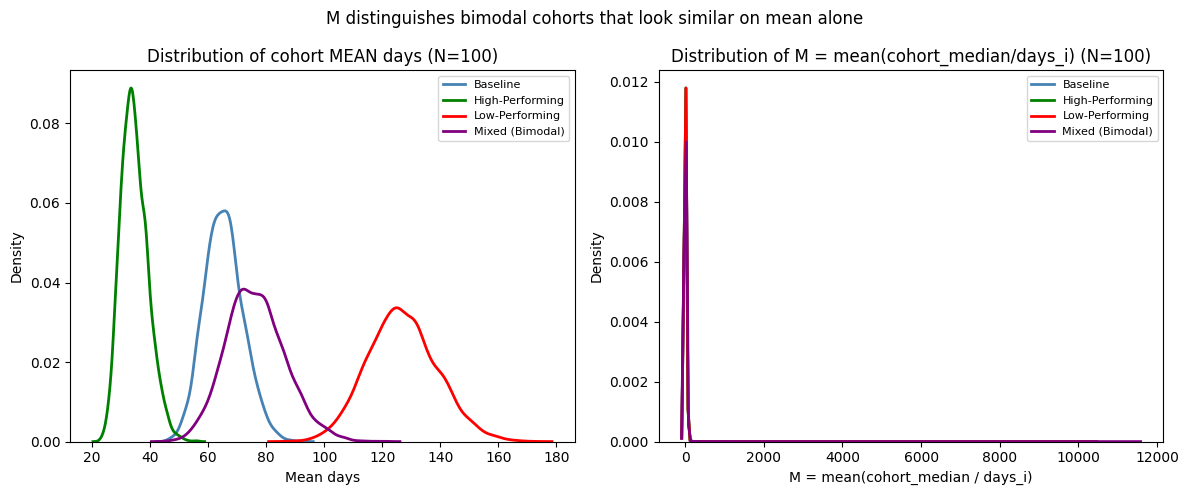


Observation: the "Mixed (Bimodal)" cohort shows a higher M than any single-distribution
scenario, even when absolute mean days partially overlap. The concentrated fast cluster
(70%) generates high cohort_median/days_i scores, while the 30% slow segment contributes
very low scores — the net mean score is elevated and clearly separated from the baseline.


In [7]:
# KDE comparison: show that bimodal scenario is distinguishable via M even when mean days overlap
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

N_COMPARE = 100
for ax, metric in zip(axes, ['cohort_mean', 'mean_score']):
    for name, by_size in sim_data.items():
        df = by_size[N_COMPARE]
        sns.kdeplot(df[metric], ax=ax, label=name, color=SCENARIOS[name]['color'], lw=2)
    ax.set_xlabel('Mean days' if metric == 'cohort_mean' else 'M = mean(cohort_median / days_i)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

axes[0].set_title(f'Distribution of cohort MEAN days (N={N_COMPARE})')
axes[1].set_title(f'Distribution of M = mean(cohort_median/days_i) (N={N_COMPARE})')
fig.suptitle('M distinguishes bimodal cohorts that look similar on mean alone', fontsize=12)
plt.tight_layout()
plt.savefig('../output/03_kde_mean_vs_M.png', dpi=150)
plt.show()

print()
print('Observation: the "Mixed (Bimodal)" cohort shows a higher M than any single-distribution')
print('scenario, even when absolute mean days partially overlap. The concentrated fast cluster')
print('(70%) generates high cohort_median/days_i scores, while the 30% slow segment contributes')
print('very low scores — the net mean score is elevated and clearly separated from the baseline.')